# Delivery lead-time regression: bounded HGB parameter tuning

## tl;dr
Training-CV winner: **leaves63__time_risk**. Five-fold MAE 4.2378 days; original random test MAE 4.1505 versus previous 4.1923 days (1.00% reduction). Test previously exposed; bounded development result, not global optimality. No new stacking.

Shared snapshot: tables and figures match the original executed experiment. Only directory bootstrap and the final local-history hash check are adapted for portable review. Model/inference checks below report the saved original verification; running this review does not retrain a model. `scripts/reproduce_best.py` rebuilds this fixed selected model from the course ZIP without earlier experiment caches.

In [1]:
from pathlib import Path
import sys,json
import pandas as pd
from IPython.display import display,Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/hgb_parameter_tuning.py').exists())
sys.path.insert(0,str(ROOT/'src'))
sys.path.insert(0,str(ROOT/'scripts'))
import hgb_parameter_tuning as m
D=ROOT/'results'
m.DEST=D
protocol=json.loads((D/'protocol.json').read_text())
display({k:protocol[k] for k in ['random_split','outer_cv','train_n','test_n','loss','classifier_tuning','stacking','test_previously_exposed']})

{'random_split': 'fixed 67/33, seed33',
 'outer_cv': 'unchanged five development folds',
 'train_n': 64634,
 'test_n': 31836,
 'loss': 'absolute_error fixed; no reweighting or target/cohort changes',
 'classifier_tuning': False,
 'stacking': False,
 'test_previously_exposed': True}

## Context & Methods
Predict fractional purchase-to-receipt days at purchase for customer service / fulfilment planning. Continue the existing linear/tree family analysis; tune only the best HGB.

### Key Assumptions
Archive seller/product/quote inputs are assumed available at purchase. Only completed valid outcomes can train the model. Date effects cannot establish future performance. Risk is a supervised transformation of existing purchase inputs; no actual slow flag is an input. Fixed-parameter nested risk construction prevents label leakage, but adaptive parameter selection on reused folds is not an unbiased nested assessment.

In [2]:
display(pd.read_csv(D/'tables/parameter_settings.csv'))
display({k:protocol[k] for k in ['stage_A','stage_B','selection','risk_generation','preprocessing']})

,configuration,loss,max_iter,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization
0,control,absolute_error,300,0.05,31,30,10
1,leaves15,absolute_error,300,0.05,15,30,10
2,leaves63,absolute_error,300,0.05,63,30,10
3,leaf15,absolute_error,300,0.05,31,15,10
4,leaf60,absolute_error,300,0.05,31,60,10
5,l2zero,absolute_error,300,0.05,31,30,0
6,rounds600,absolute_error,600,0.05,31,30,10
7,rate010,absolute_error,300,0.10,31,30,10


{'stage_A': '8 settings on time_risk; 40 CV rows, 5 original controls reused, 35 new fits',
 'stage_B': 'Stage A CV winner parameters on time-only; original time-only control reused; at most 5 new fits',
 'selection': 'minimum mean five-fold training MAE across A and B; original control first on exact tie',
 'risk_generation': 'reuse hash-verified per-outer-fold nested three-fold cross-fitted training risks; not global OOF',
 'preprocessing': 'fold-local original numeric/category/time transforms and risk scaling unchanged'}

## Data
Same fixed-course ZIP and geography V2; same 96,470 unique eligible completed orders; all 306 >60-day durations retained. No new filters, random seeds, resampling or outcomes as features. Reuse exactly the validated stage11 inner-cross-fitted risk for each regression training fold. Auxiliary classifiers remain unchanged. Final fitting uses the stage11 full-training transform and five-fold risk OOF, with its training-only inference classifier.

In [3]:
audits=pd.DataFrame(json.loads((D/'fold_audit.json').read_text()))
display(audits[['fold','fit_n','score_n','date_fit_mean','risk_fit_mean','columns']])
display(json.loads((D/'cv_verification.json').read_text()))

,fold,fit_n,score_n,date_fit_mean,risk_fit_mean,columns
0,1,51707,12927,732.770368,0.047228,"{'time_risk': 1025, 'time': 1024}"
1,2,51707,12927,732.908225,0.046991,"{'time_risk': 1024, 'time': 1023}"
2,3,51707,12927,732.727154,0.047162,"{'time_risk': 1027, 'time': 1026}"
3,4,51707,12927,732.994941,0.047466,"{'time_risk': 1027, 'time': 1026}"
4,5,51708,12926,732.717029,0.047663,"{'time_risk': 1025, 'time': 1024}"


{'fold_metric_rows_verified': 50,
 'nested_risk_boundaries_reverified': 15,
 'controls_reproduced': True,
 'time_and_risk_scaling_fold_local': True,
 'selection_training_only': True,
 'stage_B_uses_only_stage_A_selected_parameters': True,
 'prior_artifacts_unchanged': True,
 'stacking': False}

## Results
### 1. Training five-fold parameter comparison
Original controls are hash-verified reused predictions. The seven changed configurations are genuinely refit on each fold. StageB evaluates time-only only for the StageA selected parameters; it is a simplification check, not a full time-only search.

,candidate,CV_MAE,CV_SD,CV_RMSE,fit_MAE,max_iter,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization
0,control__time_risk,4.272878,0.040821,7.783383,4.096658,300,0.05,31,30,10
1,leaves15__time_risk,4.324739,0.043674,7.834444,4.248287,300,0.05,15,30,10
2,leaves63__time_risk,4.237815,0.036900,7.745040,3.881829,300,0.05,63,30,10
3,leaf15__time_risk,4.274052,0.039911,7.785259,4.092495,300,0.05,31,15,10
4,leaf60__time_risk,4.270902,0.041961,7.781221,4.101872,300,0.05,31,60,10
5,l2zero__time_risk,4.275395,0.038328,7.785962,4.102137,300,0.05,31,30,0
6,rounds600__time_risk,4.239266,0.039717,7.747465,3.917386,600,0.05,31,30,10
7,rate010__time_risk,4.241849,0.039020,7.748177,3.918632,300,0.10,31,30,10
8,control__time,4.282754,0.046693,7.846865,4.086706,300,0.05,31,30,10
9,leaves63__time,4.239900,0.047682,7.783555,3.874373,300,0.05,63,30,10


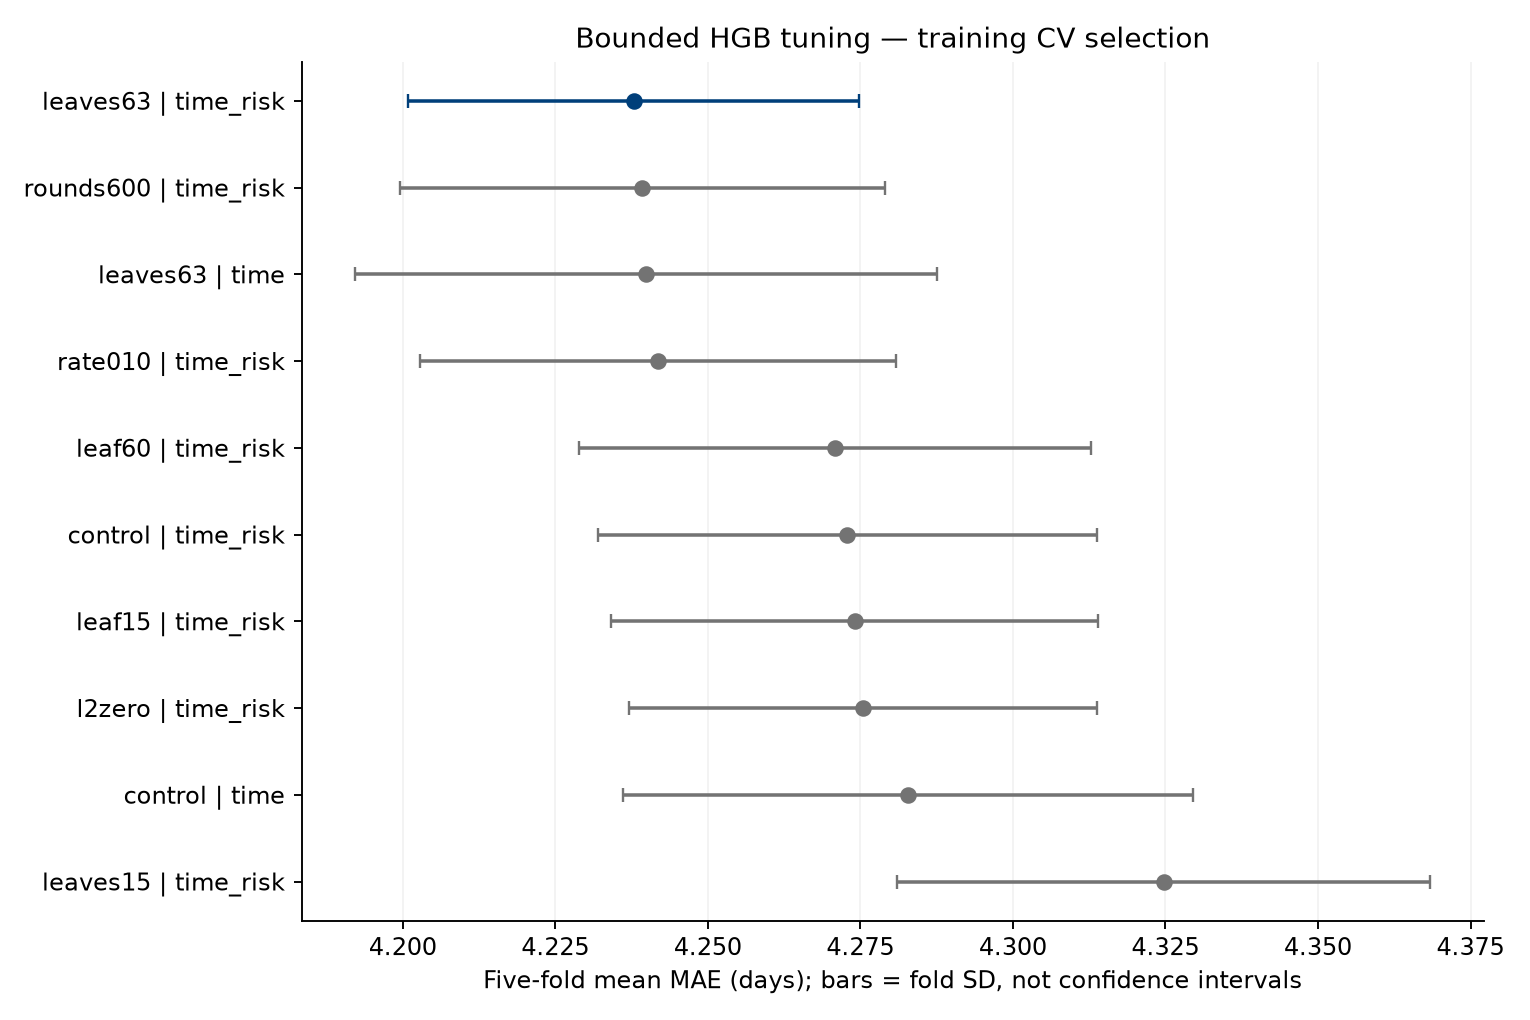

In [4]:
comparison=pd.read_csv(D/'tables/parameter_comparison.csv')
display(comparison[['candidate','CV_MAE','CV_SD','CV_RMSE','fit_MAE','max_iter','learning_rate','max_leaf_nodes','min_samples_leaf','l2_regularization']])
display(Image(filename=str(D/'figures/cv_parameter_comparison.png')))

### 2. Freeze and paired fold changes
Select by mean training CV MAE, before this-stage test scoring. Fold SD is descriptive variability, not a confidence interval. Existing folds have participated in prior development.

In [5]:
frozen=json.loads((D/'frozen_selection.json').read_text())
display(frozen)
assert frozen['frozen_before_test']
display(pd.read_csv(D/'tables/paired_fold_changes.csv'))

{'candidate': 'leaves63__time_risk',
 'configuration': 'leaves63',
 'pack': 'time_risk',
 'params': {'loss': 'absolute_error',
  'max_iter': 300,
  'learning_rate': 0.05,
  'max_leaf_nodes': 63,
  'min_samples_leaf': 30,
  'l2_regularization': 10},
 'stage_A_best_parameters': 'leaves63',
 'selection_metric': 'training five-fold mean MAE',
 'summary_sha256': '1617eb068be511b9631aed523c5bf5157b6ca7743c57f18e9eac0f58cdf900c3',
 'source_sha256': 'a9694e1709e6c534e1f8c5ee536124ba81d61b649b030c95ee4f649ddf2873e6',
 'frozen_before_test': True,
 'test_previously_exposed': True,
 'stacking': False}

,candidate,mean_MAE_reduction_days,improved_folds,min_reduction_days,max_reduction_days
0,control__time_risk,0.000000,0,0.000000,0.000000
1,leaves15__time_risk,-0.051861,0,-0.061625,-0.045156
2,leaves63__time_risk,0.035063,5,0.028868,0.043786
3,leaf15__time_risk,-0.001173,2,-0.005454,0.003433
4,leaf60__time_risk,0.001976,4,-0.000296,0.004679
5,l2zero__time_risk,-0.002517,1,-0.005398,0.001311
6,rounds600__time_risk,0.033612,5,0.026581,0.039063
7,rate010__time_risk,0.031029,5,0.021600,0.038924
8,control__time,-0.009875,1,-0.032762,0.007513
9,leaves63__time,0.032979,5,0.019621,0.043464


### 3. Previously exposed test follow-up
Only the frozen winner and two predeclared input controls are evaluated on the same 31,836 test orders. Do not pick the smallest test MAE after looking at this table; the selected candidate remains determined by CV.

,candidate,configuration,pack,role,n,MAE_days,RMSE_days,R2,bias_days,P90_abs_error_days,tail_n,tail_MAE_days,within_3_days_pct,tail_bias_days
0,control__time_risk,control,time_risk,predeclared control,31836,4.192271,7.502789,0.361135,-1.366580,9.198852,99,66.273013,56.414122,-66.273013
1,control__time,control,time,predeclared control,31836,4.195421,7.561584,0.351083,-1.438046,9.072468,99,67.376041,56.429828,-67.376041
2,leaves63__time_risk,leaves63,time_risk,CV selected,31836,4.150492,7.465069,0.367543,-1.334931,9.091400,99,66.188051,56.932404,-66.188051


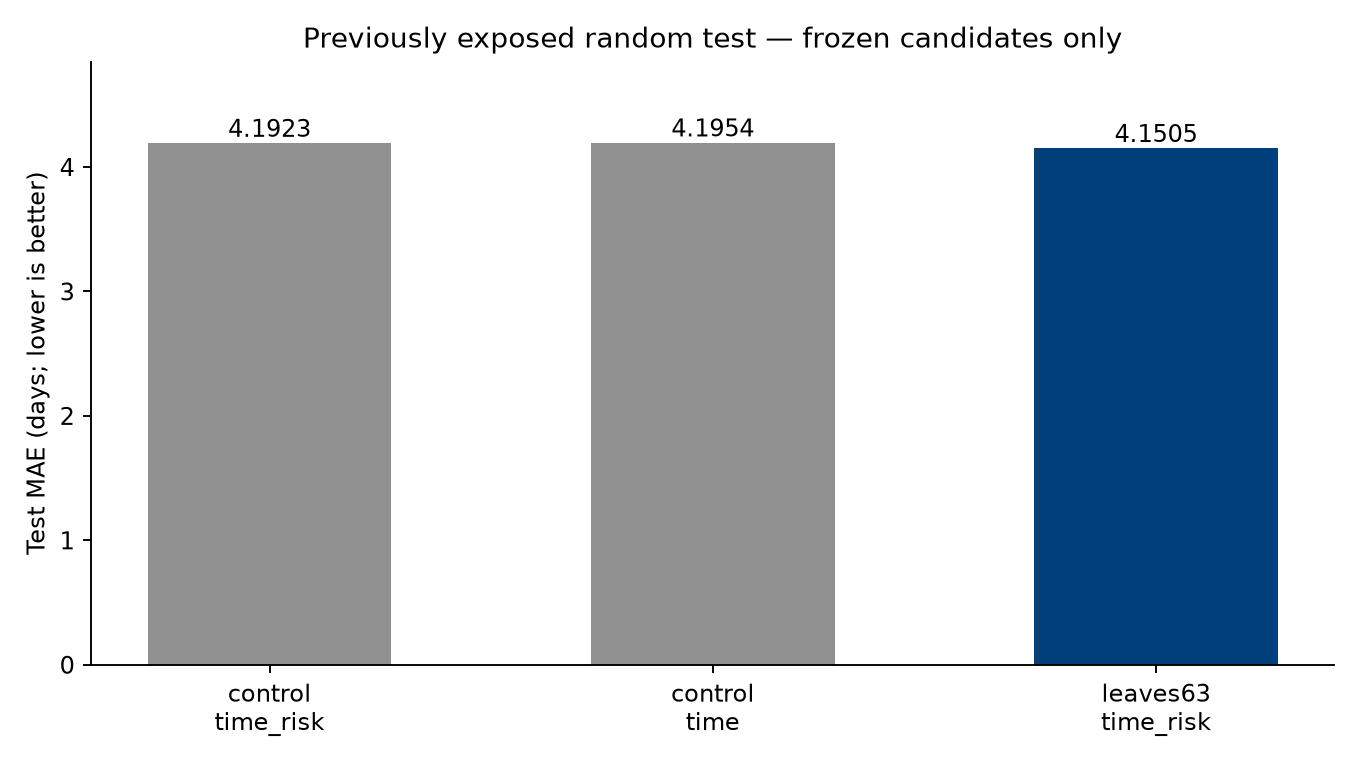

{'CV_selected_candidate': 'leaves63__time_risk',
 'params': {'loss': 'absolute_error',
  'max_iter': 300,
  'learning_rate': 0.05,
  'max_leaf_nodes': 63,
  'min_samples_leaf': 30,
  'l2_regularization': 10},
 'CV_MAE_days': 4.237815375209932,
 'CV_fold_SD_days': 0.0368997865897926,
 'previous_best_test_MAE_days': 4.192270945105909,
 'selected_test_MAE_days': 4.150491686642425,
 'test_MAE_reduction_days': 0.041779258463483515,
 'test_MAE_reduction_pct': 0.9965782033305114,
 'selected_test_RMSE_days': 7.465068534905168,
 'selected_test_R2': 0.3675426636427428,
 'within_3_days_pct': 56.93240356828747,
 'test_previously_exposed': True,
 'no_new_stacking': True,
 'search_is_bounded_not_global_optimum': True}

In [6]:
display(pd.read_csv(D/'tables/test_metrics.csv'))
display(Image(filename=str(D/'figures/test_comparison.png')))
display(json.loads((D/'result_summary.json').read_text()))

### 4. Slow-order trade-offs and independent inference checks
Compare slow slices with overall MAE/RMSE. Slice membership uses observed duration for evaluation only. Saved pipelines must predict without receipt, final status or the target.

In [7]:
display(pd.read_csv(D/'tables/test_duration_groups.csv')[['model','pack','group','n','MAE_days','bias_days']])
display(json.loads((D/'verification.json').read_text()))
from verify_bundle import verify_bundle
verify_bundle(ROOT)

,model,pack,group,n,MAE_days,bias_days
0,control,time_risk,0-14,21918,2.502213,1.156184
1,control,time_risk,14-30,8454,5.452602,-4.298285
2,control,time_risk,30-60,1365,19.021466,-19.010235
3,control,time_risk,>60,99,66.273013,-66.273013
4,control,time,0-14,21918,2.488324,1.151244
5,control,time,14-30,8454,5.340156,-4.393139
6,control,time,30-60,1365,19.934394,-19.930246
7,control,time,>60,99,67.376041,-67.376041
8,leaves63,time_risk,0-14,21918,2.482825,1.144214
9,leaves63,time_risk,14-30,8454,5.373817,-4.178718


{'test_metric_rows_verified': 3,
 'saved_models_reloaded_in_fresh_process': True,
 'outcome_columns_not_required': True,
 'duration_groups_independently_verified': True,
 'previous_best_test_MAE_reproduced': True,
 'previous_test_exposure_disclosed': True,
 'prior_artifacts_unchanged': True,
 'no_new_stacking': True}

Verified portable snapshot: 40 immutable files


{'files_checked': 40, 'all_hashes_match': True}

## Takeaways
The winner is the best of this predefined neighborhood and one documented simplification check. Original baselines and prior experiments remain available; no result is overwritten. Freeze this result for subsequent reporting/integration rather than expanding algorithms or choosing new splits for better test numbers. Deployment precision and causal operational improvements are unverified.

Training source: `src/hgb_parameter_tuning.py`; reproduction entry: `scripts/reproduce_best.py`. This executed companion reviews saved fits; expensive retraining is explicit. AI-assisted implementation and interpretation; numbers are backed by saved runs and independent checks. This shared package does not update stacking or replace the formal handoff. Results were generated locally before publication.